In [ ]:
# To config Google Colab

# Install MedMNIST and privacy tools
# !pip install medmnist fire
# !pip install opacus==1.4.0


# Verify
# import torch
# print(f"PyTorch version: {torch.__version__}")
# print(f"CUDA available: {torch.cuda.is_available()}")
# print(f"CUDA version: {torch.version.cuda if torch.cuda.is_available() else 'Not available'}")

In [5]:
from utility import set_seed, get_datasets, get_dataloaders, get_data_info, scores
from model import get_model, get_optimizer, get_loss_function

In [6]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

import glob
import medmnist
from medmnist import INFO, Evaluator
import pandas as pd
import os
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']
import time

from opacus import PrivacyEngine

## Main Training Parameters

In [7]:
data_flag = 'bloodmnist'
info = get_data_info(data_flag)

# Main training parameters
NUM_EPOCHS = 100
BATCH_SIZE = 128
LR = 0.001
n_channels = info['n_channels']
n_classes = len(info['label'])
K_max = 3  # Number of initializations for averaging results
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Early stopping parameters
PATIENCE = 10  # number of epochs we wait for improvement
MIN_DELTA = 0.01  # minimum improvement
MIN_EPOCHS = 40  # minimum number of epochs before early stopping can be triggered, must be less than NUM_EPOCHS
if MIN_EPOCHS >= NUM_EPOCHS:
    raise ValueError("MIN_EPOCHS must be less than NUM_EPOCHS for early stopping to work.")

# Privacy Parameters
C = 0.1259
EPSILON = 2
DELTA = 7*10**(-9)

## Preprocess and data loading

In [ ]:
train_dataset, val_dataset, test_dataset = get_datasets(data_flag)
train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=BATCH_SIZE)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
val_loader_at_eval = data.DataLoader(dataset=val_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [ ]:
## Model
criterion = get_loss_function(info['task'])

# Define the path to save the models
MODEL_SAVE_PATH = 'final_models/weights'

In [9]:
loss_curve_train = []
loss_curve_val = []

auc_curve_train = []
auc_curve_val = []

# only for 1 initit of weights
acc_curve_train = []
acc_curve_val = []

# K is the number of attempts to average the final accuracy and time for training

# To track metrics
best_models = []  # To store file paths of best models
early_stop_epochs = []  # To track when each run stopped
early_stop_times = []  # To track training time until early stopping
av_epoch_time = []


for K in range(3):

    # need to init model weights
    model = get_model(n_channels, n_classes)
    optimizer = get_optimizer(model, lr=LR)
    criterion = get_loss_function(info['task'])

    # Initialize PrivacyEngine
    privacy_engine = PrivacyEngine() # secure_mode=True

    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        target_epsilon=EPSILON, # Noise parameter
        target_delta = DELTA,
        epochs = NUM_EPOCHS,
        max_grad_norm=C,    # Gradient clipping norm
        loss_reduction = 'mean', #Indicates if the loss reduction (for aggregating the gradients) is a sum or a mean operation.
    )


    # Early stopping variables
    best_val_metric = 0  # For ACC (higher is better)
    best_epoch = 0
    no_improve_count = 0
    best_model_path = None

    # Time tracking
    total_time = 0
    epoch_times = []

    # For tracking metrics
    loss_curve_train = []
    loss_curve_val = []


    for epoch in range(NUM_EPOCHS):
        train_loss = 0.0
        train_batches = 0

        # Training phase
        start_epoch_time = time.perf_counter()

        model.train()
        for inputs, targets in tqdm(train_loader):

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)


            # can be used for other 2D datasets
            if info['task'] == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                loss = criterion(outputs, targets)
            else:
                targets = targets.squeeze().long()
                loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_batches += 1

        avg_train_loss = train_loss / train_batches if train_batches > 0 else 0
        loss_curve_train.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        val_batches = 0

        with torch.no_grad():

            for val_inputs, val_targets in val_loader:
                val_inputs = val_inputs.to(device)
                val_targets = val_targets.to(device)

                val_outputs = model(val_inputs)
                if info['task'] == 'multi-label, binary-class':
                    val_targets = val_targets.to(torch.float32)
                    v_loss = criterion(val_outputs, val_targets)
                else:
                    val_targets = val_targets.squeeze().long()
                    v_loss = criterion(val_outputs, val_targets)

                val_loss += v_loss.item()
                val_batches += 1

        avg_val_loss = val_loss / val_batches if val_batches > 0 else 0
        loss_curve_val.append(avg_val_loss)

        # ---- Calculate validation ACC for early stopping ----
        metric_val = scores('val', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)

        current_metric = metric_val.ACC

        end_epoch_time = time.perf_counter()
        epoch_time = end_epoch_time - start_epoch_time
        epoch_times.append(epoch_time)
        total_time += epoch_time
        av_epoch_time.append(epoch_time)

        # we save acc and auc curves only for 1 initialization as they don't significantly differ + evaluation takes time
        if K == 0:
            metric_train = scores('train', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)

            auc_curve_train.append(metric_train.AUC)
            acc_curve_train.append(metric_train.ACC)

            metric_val = scores('val', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
            auc_curve_val.append(metric_val.AUC)
            acc_curve_val.append(metric_val.ACC)

        print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}, val loss: {avg_val_loss:.4f}")
        print(f"Epoch {epoch+1} training time: {epoch_time:.2f} seconds")

        epsilon = privacy_engine.get_epsilon(DELTA)
        print(f"Privacy cost: (ε = {epsilon:.2f}, δ = {DELTA})")

        # Early stopping check
        if epoch > MIN_EPOCHS and current_metric > best_val_metric + MIN_DELTA:
            print(f"Validation metric improved from {best_val_metric:.4f} to {current_metric:.4f}")
            best_val_metric = current_metric
            best_epoch = epoch
            no_improve_count = 0

            # Save best model with updated path
            model_filename = f'model_init_{K}_best_epoch_{epoch}_auc_{metric_val.AUC:.4f}_acc_{metric_val.ACC:.4f}.pth'
            model_path = os.path.join(MODEL_SAVE_PATH, model_filename)

            # Check if model has the _module attribute (from privacy engine)
            if hasattr(model, '_module'):
                torch.save(model._module.state_dict(), model_path)
            else:
                torch.save(model.state_dict(), model_path)

            best_model_path = model_path
            print(f"Saved best model to {model_path}")
        else:
            if epoch > MIN_EPOCHS:
                no_improve_count += 1
                print(f"No improvement for {no_improve_count} epochs")

        # Check if we should stop
        if epoch > MIN_EPOCHS and no_improve_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Training phase finishes here
    early_stop_epochs.append(best_epoch + 1)  # +1 for 1-based indexing
    early_stop_times.append(total_time)
    best_models.append(best_model_path)

    # epsilon = accountant.get_epsilon(delta=DELTA)
    # print(f"Epsilon: {epsilon}")


    print("--------------------------------")
    print(f"Instance {K}")
    print(f"Best epoch: {best_epoch + 1}")
    print(f"Best validation ACC: {best_val_metric:.4f}")
    print(f"Training time until best model: {sum(epoch_times[:best_epoch+1]):.2f} seconds")
    print(f"Total training time: {total_time:.2f} seconds")



Using device: cuda


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:142: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opacus/accountants/analysis/prv/prvs.py:50: RuntimeWarning: invalid value encountered in log
  z = np.log((np.exp(t) + q - 1) / q)
  0%|          | 0/94 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missin

Epoch 1 train loss: 1.9597, val loss: 1.8242
Epoch 1 training time: 5.99 seconds
Privacy cost: (ε = 0.20, δ = 7.000000000000001e-09)


  0%|          | 0/94 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
100%|██████████| 94/94 [00:04<00:00, 20.07it/s]
/usr/local/lib/python3.11/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opacus/accountants/analysis/prv/prvs.py:50: RuntimeWarning: invalid value encountered in log
  z = np.log((np.exp(t) + q - 1) / q)


Epoch 2 train loss: 1.6685, val loss: 1.5302
Epoch 2 training time: 5.48 seconds
Privacy cost: (ε = 0.28, δ = 7.000000000000001e-09)


...


  0%|          | 0/94 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
100%|██████████| 94/94 [00:04<00:00, 20.08it/s]
/usr/local/lib/python3.11/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opacus/accountants/analysis/prv/prvs.py:50: RuntimeWarning: invalid value encountered in log
  z = np.log((np.exp(t) + q - 1) / q)


Epoch 61 train loss: 1.0131, val loss: 1.0008
Epoch 61 training time: 5.46 seconds
Privacy cost: (ε = 1.54, δ = 7.000000000000001e-09)
No improvement for 9 epochs



  0%|          | 0/94 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
100%|██████████| 94/94 [00:05<00:00, 16.09it/s]


Epoch 62 train loss: 1.0019, val loss: 1.0047
Epoch 62 training time: 6.64 seconds
Privacy cost: (ε = 1.55, δ = 7.000000000000001e-09)
No improvement for 10 epochs
Early stopping at epoch 62
--------------------------------
Instance 2
Best epoch: 52
Best validation ACC: 0.7593
Training time until best model: 303.46 seconds
Total training time: 363.16 seconds


/usr/local/lib/python3.11/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/opacus/accountants/analysis/prv/prvs.py:50: RuntimeWarning: invalid value encountered in log
  z = np.log((np.exp(t) + q - 1) / q)


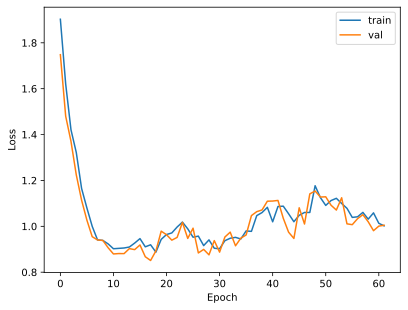

In [22]:
# the first trained model is shown
plt.plot(loss_curve_train, label='train')
plt.plot(loss_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"Loss_vs_Epochs_C={C}_epsilon={EPSILON}_Batch_size_{BATCH_SIZE}_lr_{LR}.png", dpi=300)

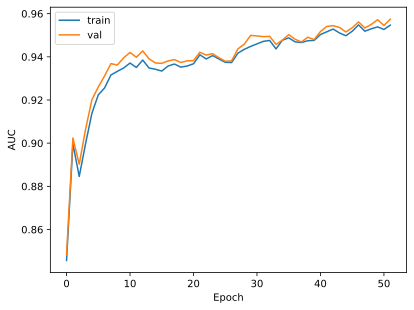

In [12]:
# the first trained model is shown
plt.plot(auc_curve_train, label='train')
plt.plot(auc_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.savefig(f"AUC_vs_Epochs_C={C}_epsilon={EPSILON}_Batch_size_{BATCH_SIZE}_lr_{LR}.png", dpi=300)

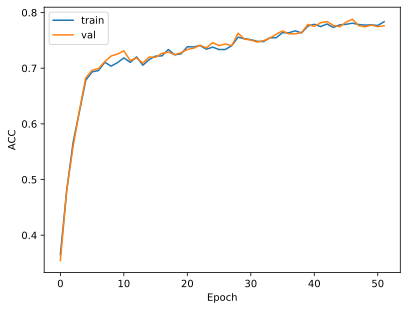

In [13]:
plt.plot(acc_curve_train, label='train')
plt.plot(acc_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('ACC')
plt.legend()
plt.savefig(f"ACC_vs_Epochs_C={C}_epsilon={EPSILON}_Batch_size_{BATCH_SIZE}_lr_{LR}.png", dpi=300)

## Evaluation

In [ ]:
print('==> Evaluating ...')
final_auc_train = []
final_acc_train = []

final_auc_test = []
final_acc_test = []

for i, model_path in enumerate(best_models):


    model = get_model(n_channels, n_classes)
    state_dict = torch.load(model_path)
    model.load_state_dict(state_dict)
    model.eval()

    metric_train = scores('train', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
    final_auc_train.append(metric_train.AUC)
    final_acc_train.append(metric_train.ACC)

    metric_test = scores('test', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
    final_auc_test.append(metric_test.AUC)
    final_acc_test.append(metric_test.ACC)

print("--------------------------------------------------")
print(f"Average stopping epoch: {np.mean(early_stop_epochs):.1f} ± {np.std(early_stop_epochs):.1f}")
print(f"Average training time: {np.mean(early_stop_times):.2f} ± {np.std(early_stop_times):.2f} seconds")
print(f"Average epoch time: {np.mean(av_epoch_time):.2f} ± {np.std(av_epoch_time):.2f} seconds")
print(f"Batch size:", BATCH_SIZE)
print(f"Learning rate:", LR)

print("--------------------------------------------------")
print(f"Clipping parameter: {C}")
print(f"Privacy parameters: {EPSILON, DELTA}")
print("--------------------------------------------------")
print(f"ACC (train): {np.mean(final_acc_train):.4f}  ± {np.std(final_acc_train):.4f}")
print(f"AUC (train): {np.mean(final_auc_train):.4f} ± {np.std(final_auc_train):.4f}")
print("--------------------------------------------------")
print(f"ACC (test): {np.mean(final_acc_test):.4f} ± {np.std(final_acc_test):.4f}")
print(f"AUC (test): {np.mean(final_auc_test):.4f} ± {np.std(final_auc_test):.4f}")

==> Evaluating ...
Using device: cuda
Using device: cuda
Using device: cuda
--------------------------------------------------
Average stopping epoch: 51.0 ± 7.0
Average training time: 360.33 ± 41.05 seconds
Average epoch time: 5.91 ± 0.48 seconds
Batch size: 128
Learning rate: 0.001
--------------------------------------------------
Clipping parameter: 0.1259
Privacy parameters: (2, 7.000000000000001e-09)
--------------------------------------------------
ACC (train): 0.7754  ± 0.0226
AUC (train): 0.9538 ± 0.0099
--------------------------------------------------
ACC (test): 0.7715 ± 0.0217
AUC (test): 0.9522 ± 0.0103
